# Checkpoint 2: Pneumonia Detection from Chest X-Rays

## Summary

This notebook is prepared for the second project checkpoint: data understanding, preprocessing, and baseline model performance.

It documents and generates:
- dataset source and Kaggle download setup
- original Kaggle split counts and the reason for replacing the tiny validation split
- a reproducible stratified 80/10/10 train/validation/test split
- class imbalance analysis, sample image review, and visual observations
- patient-level leakage discussion and the limitation of image-level splitting
- preprocessing and online, training-only augmentation steps
- augmentation count and class-distribution behavior
- a baseline CNN model with an architecture table
- training curves, ROC-AUC, PR-AUC, threshold analysis, classification report, and confusion matrix

The purpose of the baseline is not to produce a final medical model. It gives an early reference point for the pipeline and helps identify issues to address before the final submission, such as class imbalance, validation stability, false negatives, and threshold choice.

Generated files are saved under `outputs/`, while `checkpoint2_report.md` provides a short report for Moodle submission.

Binary image classification - **NORMAL** vs **PNEUMONIA** chest X-rays.

**Dataset:** [Kaggle - Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney

**Python version used for this project:** `3.13.8`
**Dependency file:** `requirements.txt`

**Sections:**
0. Dataset download and setup
0.1. Configuration
1. Data exploration, quality review, and split
2. Preprocessing and augmentation
3. Baseline CNN model
4. Baseline training
5. Baseline evaluation and metrics
6. Transfer learning: MobileNetV2
7. Transfer learning: DenseNet121
8. Final model comparison
9. Grad-CAM explainability
10. Findings, limitations, and report notes

## How to Run This Notebook

### Local setup in VS Code
Run these commands once in a PowerShell terminal from the project folder:
```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -U pip
python -m pip install -r requirements.txt
```
Then select `.venv` as the notebook kernel in VS Code. After that, you can skip the dependency install cell unless packages are missing or changed.

For Kaggle locally, either set `KAGGLE_API_TOKEN` before launching VS Code/Jupyter, or put your token in `<your-home-folder>\.kaggle\access_token` with no `.txt` extension. On Windows this is usually `C:\Users\<your-username>\.kaggle\access_token`.

To set the environment variable for the current PowerShell session only:
```powershell
$env:KAGGLE_API_TOKEN = "paste-your-token-here"
```

To save it permanently for your Windows user account, run this once, then restart VS Code so the notebook kernel inherits it:
```powershell
[Environment]::SetEnvironmentVariable("KAGGLE_API_TOKEN", "paste-your-token-here", "User")
```

### Google Colab setup
Run the dependency install cell each time you start a fresh Colab runtime. For faster training, go to **Runtime -> Change runtime type -> T4 GPU** before running the training cells.

For Kaggle in Colab, the recommended option is Colab Secrets:
1. Open the left sidebar and click the key icon (**Secrets**).
2. Add a secret named `KAGGLE_API_TOKEN`.
3. Paste your Kaggle token as the value and allow notebook access.

Fallback option: save your token text in Google Drive at `MyDrive/secrets/kaggle_token.txt`. The dataset setup cell can mount Drive and load it if no Colab Secret is found.

### Shared cells
The dependency and dataset setup cells are written to work in both local VS Code and Google Colab. They follow the active notebook kernel, so local runs use `.venv` when that kernel is selected, while Colab runs use the Colab runtime.


In [1]:
import subprocess
import sys
from pathlib import Path

# Install the exact libraries needed by this notebook runtime.
# In VS Code this uses the selected kernel; in Colab it uses the active Colab runtime.
requirements_path = Path('requirements.txt')

if requirements_path.exists():
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '-r', str(requirements_path)],
        check=True,
    )
else:
    DEPENDENCIES = [
        'tensorflow',
        'numpy',
        'pandas',
        'matplotlib',
        'scikit-learn',
        'seaborn',
        'pillow',
        'kaggle',
    ]
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', *DEPENDENCIES],
        check=True,
    )

print(f'Dependencies installed for: {sys.executable}')
print(f'Python version: {sys.version.split()[0]}')


Dependencies installed for: /usr/bin/python3
Python version: 3.12.13


## 0 - Dataset Setup

This section downloads the Chest X-Ray Pneumonia dataset with the Kaggle API. Use the credential setup from **How to Run This Notebook** above before running the cell.

### Local VS Code
- The cell accepts either `KAGGLE_API_TOKEN` or `<your-home-folder>\.kaggle\access_token`.
- If you set `KAGGLE_API_TOKEN`, restart VS Code/Jupyter before running the notebook so the kernel can see it.

### Google Colab
- First choice: add `KAGGLE_API_TOKEN` in the Colab Secrets panel and allow notebook access.
- Fallback: save the token in Drive at `MyDrive/secrets/kaggle_token.txt`.
- The next cell tries Colab Secrets first, then mounts Drive only if the secret is not found.

The notebook expects the dataset at `chest_xray/train...`, `chest_xray/val...`, and `chest_xray/test...`. After download it removes Kaggle archive clutter like `chest_xray/chest_xray` and `chest_xray/__MACOSX`, then prints image counts.

In [2]:
import os
import shutil
import sys
from pathlib import Path

KAGGLE_DATASET = 'paultimothymooney/chest-xray-pneumonia'
KAGGLE_TOKEN_ENV = 'KAGGLE_API_TOKEN'
COLAB_TOKEN_PATH = Path('/content/drive/MyDrive/secrets/kaggle_token.txt')
KAGGLE_DIR = Path.home() / '.kaggle'
EXPECTED_SPLITS = ('train', 'val', 'test')
EXPECTED_CLASSES = ('NORMAL', 'PNEUMONIA')
VALID_EXTENSIONS = {'.jpeg', '.jpg', '.png', '.bmp'}

try:
    from google.colab import drive, userdata
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

DOWNLOAD_DIR = Path('/content') if RUNNING_IN_COLAB else Path.cwd()
DATASET_DIR = DOWNLOAD_DIR / 'chest_xray'

if RUNNING_IN_COLAB:
    colab_secret = userdata.get(KAGGLE_TOKEN_ENV)
    if colab_secret:
        os.environ[KAGGLE_TOKEN_ENV] = colab_secret
        auth_source = f'Colab Secret: {KAGGLE_TOKEN_ENV}'
    else:
        drive.mount('/content/drive')
        if not COLAB_TOKEN_PATH.exists():
            raise FileNotFoundError(
                f'Kaggle token not found. Add Colab Secret {KAGGLE_TOKEN_ENV}, '
                f'or create {COLAB_TOKEN_PATH}.'
            )
        os.environ[KAGGLE_TOKEN_ENV] = COLAB_TOKEN_PATH.read_text(encoding='utf-8').strip()
        auth_source = f'Colab/Drive token: {COLAB_TOKEN_PATH}'
elif os.environ.get(KAGGLE_TOKEN_ENV):
    auth_source = f'environment variable: {KAGGLE_TOKEN_ENV}'
elif (KAGGLE_DIR / 'access_token').exists():
    token_path = KAGGLE_DIR / 'access_token'
    os.environ[KAGGLE_TOKEN_ENV] = token_path.read_text(encoding='utf-8').strip()
    auth_source = f'token file: {token_path}'
else:
    raise EnvironmentError(
        f'No Kaggle credentials found. Set {KAGGLE_TOKEN_ENV}, '
        f'or create {KAGGLE_DIR / "access_token"}.'
    )

active_token = os.environ.get(KAGGLE_TOKEN_ENV, '')
token_preview = f'{active_token[:4]}...{active_token[-4:]}'
print(f'Kaggle auth source: {auth_source}')
print(f'Kaggle token preview: {token_preview}')

from kaggle.api.kaggle_api_extended import KaggleApi

print(f'Downloading/extracting {KAGGLE_DATASET} into {DOWNLOAD_DIR}')
api = KaggleApi()
api.authenticate()
api.dataset_download_files(KAGGLE_DATASET, path=str(DOWNLOAD_DIR), unzip=True, quiet=False)

missing = [DATASET_DIR / split / cls
           for split in EXPECTED_SPLITS for cls in EXPECTED_CLASSES
           if not (DATASET_DIR / split / cls).is_dir()]
if missing:
    raise FileNotFoundError('Missing expected dataset folders: ' + ', '.join(str(path) for path in missing))

for extra_path in (DATASET_DIR / 'chest_xray', DATASET_DIR / '__MACOSX'):
    if extra_path.exists():
        shutil.rmtree(extra_path)
        print(f'Removed archive clutter: {extra_path}')

print(f'Dataset root: {DATASET_DIR}')
for split in EXPECTED_SPLITS:
    counts = {}
    for cls in EXPECTED_CLASSES:
        folder = DATASET_DIR / split / cls
        counts[cls] = sum(1 for file in folder.iterdir() if file.suffix.lower() in VALID_EXTENSIONS)
    total = sum(counts.values())
    print(f'{split:5s} total={total:4d} | NORMAL={counts["NORMAL"]:4d} | PNEUMONIA={counts["PNEUMONIA"]:4d}')

Kaggle auth source: Colab Secret: KAGGLE_API_TOKEN
Kaggle token preview: KGAT...8e53
Downloading/extracting paultimothymooney/chest-xray-pneumonia into /content
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:21<00:00, 117MB/s]



Removed archive clutter: /content/chest_xray/chest_xray
Removed archive clutter: /content/chest_xray/__MACOSX
Dataset root: /content/chest_xray
train total=5216 | NORMAL=1341 | PNEUMONIA=3875
val   total=  16 | NORMAL=   8 | PNEUMONIA=   8
test  total= 624 | NORMAL= 234 | PNEUMONIA= 390


## 0.1 - Configuration

All paths and hyperparameters are defined here. The raw Kaggle folders are kept unchanged, but the training pipeline below creates a reproducible stratified 80/10/10 split across all downloaded images.

In [3]:
import sys
from pathlib import Path

# Use /content in Colab and the project folder locally, so the same notebook runs in both places.
BASE_DIR = Path('/content') if 'google.colab' in sys.modules else Path.cwd()
DATASET_DIR = BASE_DIR / 'chest_xray'
OUTPUT_DIR  = BASE_DIR / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
RESULTS_DIR = OUTPUT_DIR / 'results'
MODELS_DIR  = OUTPUT_DIR / 'models'

# Expected Kaggle folder names and allowed image formats.
EXPECTED_SPLITS  = ('train', 'val', 'test')
EXPECTED_CLASSES = ('NORMAL', 'PNEUMONIA')
VALID_EXTENSIONS = {'.jpeg', '.jpg', '.png', '.bmp'}

# The original Kaggle validation split is too small, so we create our own split later.
WORKING_SPLIT_RATIOS = {'train': 0.80, 'val': 0.10, 'test': 0.10}

# Core model/training settings kept in one place for easy experiments.
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 10
RANDOM_SEED = 42

# Create output folders before any plots, CSVs, or models are saved.
for d in (FIGURES_DIR, RESULTS_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'  Dataset : {DATASET_DIR}')
print(f'  Outputs : {OUTPUT_DIR}')
print(f'  Working split : {WORKING_SPLIT_RATIOS}')
print(f'  Image size={IMAGE_SIZE}  Batch size={BATCH_SIZE}  Epochs={EPOCHS}')


Configuration loaded.
  Dataset : /content/chest_xray
  Outputs : /content/outputs
  Working split : {'train': 0.8, 'val': 0.1, 'test': 0.1}
  Image size=(224, 224)  Batch size=32  Epochs=10


## 1 - Data Exploration, Quality Review, and Split

The original Kaggle validation folder contains only 16 images, which is too small for reliable model selection. With such a small validation set, a few individual images can strongly change validation accuracy or loss.

To follow the recommended project setup, this notebook combines all downloaded images and creates a reproducible stratified 80/10/10 split. Stratification keeps the class proportions similar in train, validation, and test sets. The original Kaggle test folder is therefore treated as part of the raw downloaded data, while the final evaluation uses the newly generated 10% test split.

This is a practical checkpoint choice: it gives a much larger validation set while keeping a separate held-out test set for baseline evaluation.

**Patient-level leakage note:** this Kaggle release does not provide explicit patient IDs in a separate metadata table, and the filenames are not documented as reliable patient identifiers. The split below is therefore an image-level stratified split, not a guaranteed patient-level split. If patient IDs were available, the safer approach would be a grouped split such as `GroupShuffleSplit`, ensuring all images from one patient stay in only one of train, validation, or test. This remains an important limitation for medical AI evaluation.


Original Kaggle split:
class           NORMAL  PNEUMONIA
original_split                   
test               234        390
train             1341       3875
val                  8          8

Working 80/10/10 split used for training:
class  NORMAL  PNEUMONIA
split                   
test      158        428
train    1266       3418
val       159        427


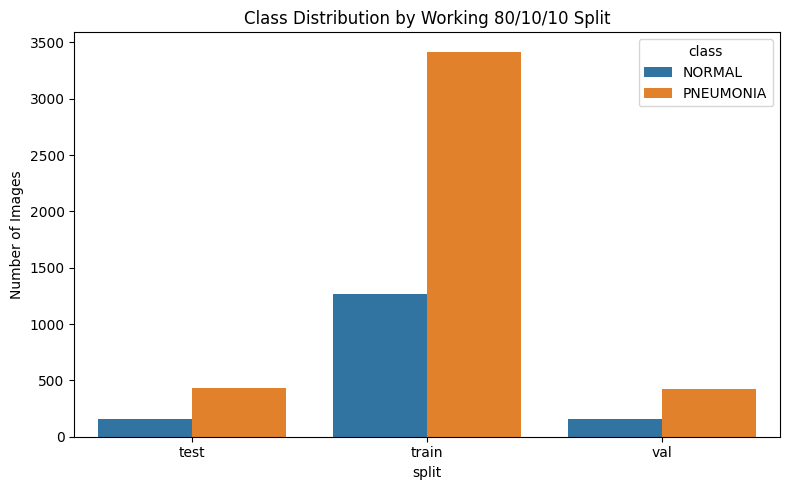

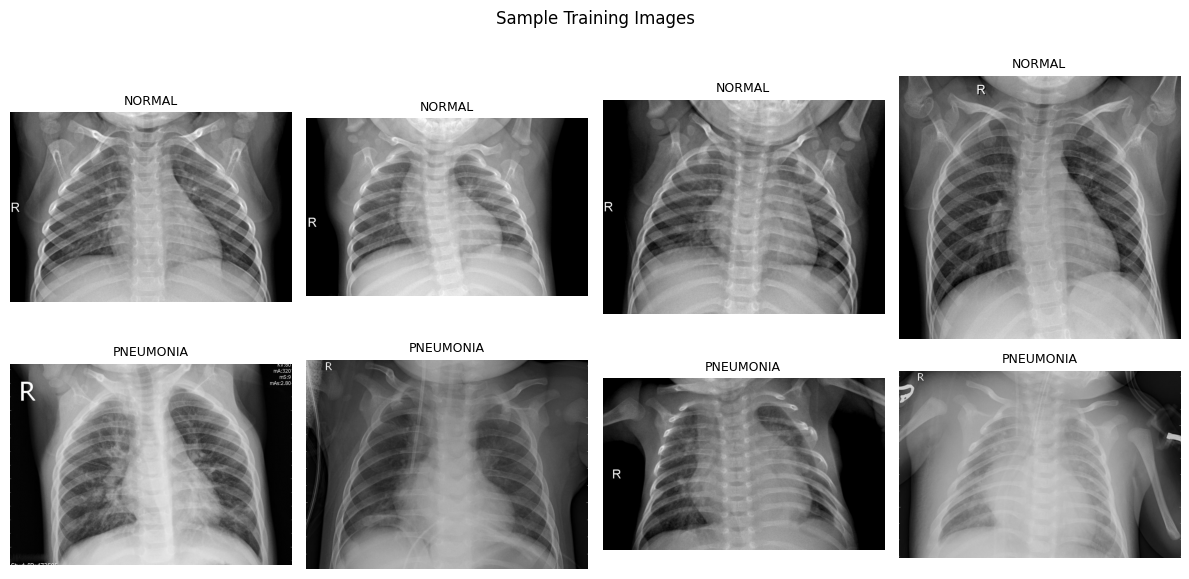

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

def _list_images(directory):
    return sorted(
        f for f in directory.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    )

# Verify raw Kaggle dataset structure
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset not found at {DATASET_DIR}. Run the download cell first.')

missing = [DATASET_DIR / split / cls
           for split in EXPECTED_SPLITS for cls in EXPECTED_CLASSES
           if not (DATASET_DIR / split / cls).exists()]
if missing:
    raise FileNotFoundError('Missing expected dataset folders: ' + ', '.join(str(path) for path in missing))

# Count original Kaggle split, then build one manifest containing all images.
rows = []
for original_split in EXPECTED_SPLITS:
    for cls in EXPECTED_CLASSES:
        for image_path in _list_images(DATASET_DIR / original_split / cls):
            rows.append({
                'path': str(image_path),
                'class': cls,
                'original_split': original_split,
            })

all_images_df = pd.DataFrame(rows)
original_summary_df = (
    all_images_df.groupby(['original_split', 'class'])
    .size()
    .reset_index(name='count')
)
original_summary_df.to_csv(RESULTS_DIR / 'dataset_original_kaggle_split.csv', index=False)
print('Original Kaggle split:')
print(original_summary_df.pivot(index='original_split', columns='class', values='count').fillna(0).astype(int))

# Create a reproducible stratified 80/10/10 split over all downloaded images.
train_df, temp_df = train_test_split(
    all_images_df,
    train_size=WORKING_SPLIT_RATIOS['train'],
    stratify=all_images_df['class'],
    random_state=RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['class'],
    random_state=RANDOM_SEED,
)

train_df = train_df.assign(split='train')
val_df = val_df.assign(split='val')
test_df = test_df.assign(split='test')
split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_df = split_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
split_df.to_csv(RESULTS_DIR / 'dataset_split_80_10_10.csv', index=False)

summary_df = split_df.groupby(['split', 'class']).size().reset_index(name='count')
summary_df.to_csv(RESULTS_DIR / 'dataset_summary.csv', index=False)
print('\nWorking 80/10/10 split used for training:')
print(summary_df.pivot(index='split', columns='class', values='count').fillna(0).astype(int))

# Class distribution bar plot for the working split.
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x='split', y='count', hue='class')
plt.title('Class Distribution by Working 80/10/10 Split')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

# Sample image grid from the working training split.
MAX_PER_CLASS = 4
fig, axes = plt.subplots(2, MAX_PER_CLASS, figsize=(3 * MAX_PER_CLASS, 6), squeeze=False)
for row_idx, cls in enumerate(EXPECTED_CLASSES):
    samples = split_df[(split_df['split'] == 'train') & (split_df['class'] == cls)]['path'].head(MAX_PER_CLASS)
    for col_idx in range(MAX_PER_CLASS):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            ax.imshow(Image.open(samples.iloc[col_idx]).convert('L'), cmap='gray')
            ax.set_title(cls, fontsize=9)
        ax.axis('off')
plt.suptitle('Sample Training Images', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'example_images_grid.png', dpi=150)
plt.show()

In [5]:
# Basic image-quality review on a small sample from each class.
# This complements manual visual inspection of the saved example grid.
import numpy as np
from IPython.display import display

QUALITY_SAMPLE_PER_CLASS = 12
quality_rows = []

for cls in EXPECTED_CLASSES:
    class_train_df = split_df[(split_df['split'] == 'train') & (split_df['class'] == cls)]
    sample_paths = class_train_df.sample(
        n=min(QUALITY_SAMPLE_PER_CLASS, len(class_train_df)),
        random_state=RANDOM_SEED,
    )['path']

    for image_path in sample_paths:
        image = Image.open(image_path).convert('L')
        array = np.asarray(image, dtype=np.float32)
        grad_x = np.diff(array, axis=1)
        grad_y = np.diff(array, axis=0)
        sharpness_proxy = float(grad_x.var() + grad_y.var())

        quality_rows.append({
            'path': image_path,
            'class': cls,
            'width': image.width,
            'height': image.height,
            'mean_brightness': float(array.mean()),
            'contrast_std': float(array.std()),
            'sharpness_proxy': sharpness_proxy,
            'low_contrast_flag': bool(array.std() < 25),
            'possible_blur_flag': bool(sharpness_proxy < 50),
        })

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(RESULTS_DIR / 'image_quality_sample.csv', index=False)

quality_summary_df = (
    quality_df.groupby('class')
    .agg(
        sampled_images=('path', 'count'),
        median_width=('width', 'median'),
        median_height=('height', 'median'),
        median_contrast_std=('contrast_std', 'median'),
        median_sharpness_proxy=('sharpness_proxy', 'median'),
        low_contrast_flags=('low_contrast_flag', 'sum'),
        possible_blur_flags=('possible_blur_flag', 'sum'),
    )
    .reset_index()
)
quality_summary_df.to_csv(RESULTS_DIR / 'image_quality_summary.csv', index=False)

print('Sample image-quality summary:')
display(quality_summary_df)
print(f"Saved sample-level quality review to {RESULTS_DIR / 'image_quality_sample.csv'}")


Sample image-quality summary:


,class,sampled_images,median_width,median_height,median_contrast_std,median_sharpness_proxy,low_contrast_flags,possible_blur_flags
0,NORMAL,12,1579.0,1242.5,63.605694,40.529455,0,9
1,PNEUMONIA,12,1292.0,844.0,54.280472,51.402252,0,6


Saved sample-level quality review to /content/outputs/results/image_quality_sample.csv


### Manual Image Quality and Visual Inspection Notes

The sample grid and the quality-summary cell above are used as a lightweight manual inspection step. The images are generally recognizable chest X-rays, but the dataset shows expected real-world variation: different image sizes, brightness, contrast, patient positioning, and visible lung-field coverage. Some images appear visually harder than others because pneumonia patterns can be subtle, local, or low contrast.

From a non-expert medical perspective, the visual difference between **NORMAL** and **PNEUMONIA** examples is not always obvious. Pneumonia images may show cloudier or more opaque regions in parts of the lungs, while normal examples often look clearer, but these patterns are not consistently easy to identify without radiology training. This supports the need for quantitative evaluation beyond visual inspection.

The quality checks are not a diagnostic tool. They only help identify whether the image sample contains obvious technical problems such as very low contrast or likely blur. A final medical project would ideally include a larger radiologist-guided quality review.


## 2 - Preprocessing & Data Augmentation

Each image path from the 80/10/10 split manifest is loaded, decoded, resized to **224x224**, converted to three channels, and scaled to `[0, 1]`.

The original X-rays are grayscale, but the model input is converted to three channels so the same preprocessing style can later support transfer learning with pretrained CNNs. Data augmentation is applied only to the training split, never to validation or test data, so evaluation remains deterministic.

**How many training examples are seen after augmentation?** The training split contains **4,684 original images**: **1,266 NORMAL** and **3,418 PNEUMONIA**. Augmentation is performed **online during training** with Keras random layers inside the `tf.data` pipeline. This means the notebook does not create extra augmented files on disk and does not permanently increase the dataset size. Each epoch still iterates over 4,684 training images, but the model can see a different randomly transformed version of an image in different epochs.

**Class distribution after augmentation:** because augmentation is online and is applied uniformly to training batches, it preserves the original training-set class distribution. It does not oversample NORMAL images and does not rebalance the dataset by itself. Later transfer-learning experiments use class weights to reduce the effect of the imbalance, but the baseline CNN keeps the original distribution.

The augmentation is intentionally mild: small rotations, zoom, horizontal flips, and contrast changes. These transformations are chosen to model small acquisition and positioning differences without changing the class label. Horizontal flipping is included cautiously: for this binary task, pneumonia can occur in either lung, and the target label is presence/absence of pneumonia rather than left/right localization. However, horizontal flipping would be less appropriate for tasks where laterality matters, such as detecting a left-sided condition or estimating anatomical orientation. This is therefore a reasonable but explicitly limited augmentation choice.


In [6]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
CLASS_TO_LABEL = {cls: index for index, cls in enumerate(EXPECTED_CLASSES)}

def decode_image(path, label):
    # Load each image from disk, force one grayscale channel, and resize consistently.
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, IMAGE_SIZE)

    # Scale pixels to [0, 1] and convert to 3 channels for CNN compatibility.
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)

def get_augmentation_layer():
    # Mild augmentation is used only for training data, never validation/test data.
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomContrast(0.1),
    ], name='augmentation')

def dataframe_to_dataset(dataframe, shuffle=False, augment=False, augmentation_layer=None):
    # Convert the split manifest rows into a performant tf.data pipeline.
    paths = dataframe['path'].to_numpy()
    labels = dataframe['class'].map(CLASS_TO_LABEL).to_numpy(dtype='float32')
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)

    if augment and augmentation_layer is not None:
        dataset = dataset.map(
            lambda images, labels: (augmentation_layer(images, training=True), labels),
            num_parallel_calls=AUTOTUNE,
        )

    return dataset.prefetch(AUTOTUNE)

def create_datasets():
    # Build three separate datasets from the reproducible 80/10/10 manifest.
    aug_layer = get_augmentation_layer()
    train_ds = dataframe_to_dataset(split_df[split_df['split'] == 'train'], shuffle=True, augment=True, augmentation_layer=aug_layer)
    val_ds   = dataframe_to_dataset(split_df[split_df['split'] == 'val'])
    test_ds  = dataframe_to_dataset(split_df[split_df['split'] == 'test'])
    class_names = list(EXPECTED_CLASSES)
    return train_ds, val_ds, test_ds, class_names

print('Preprocessing functions ready.')


Preprocessing functions ready.


## 3 - Baseline CNN Model

The baseline model is a small convolutional neural network built from scratch. It uses three `Conv2D + MaxPooling` blocks with 32, 64, and 128 filters, followed by dropout, a dense hidden layer, and a sigmoid output.

The goal is to establish a simple reference model before trying stronger approaches. Because this is a baseline, the architecture is intentionally easy to understand rather than highly optimized.

The next code cell prints both the Keras summary and a compact architecture table with layer names, output shapes, and parameter counts.

The model is compiled with:
- Adam optimizer
- binary cross-entropy loss
- accuracy, precision, and recall metrics

For this medical screening task, recall is especially important because false negatives mean pneumonia cases predicted as normal.


In [7]:
def build_baseline_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)):
    # A small CNN baseline: simple enough to interpret before trying transfer learning.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Convolution blocks learn local visual patterns; pooling reduces spatial size.
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),

        # One sigmoid output is appropriate for binary NORMAL/PNEUMONIA classification.
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model

model = build_baseline_model()
model.summary()

architecture_rows = []
for layer in model.layers:
    output_shape = getattr(layer.output, 'shape', None)
    architecture_rows.append({
        'Layer': layer.__class__.__name__,
        'Name': layer.name,
        'Output shape': str(tuple(output_shape)) if output_shape is not None else 'unknown',
        'Parameters': layer.count_params(),
    })

architecture_df = pd.DataFrame(architecture_rows)
architecture_df.to_csv(RESULTS_DIR / 'baseline_architecture.csv', index=False)
display(architecture_df)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

,Layer,Name,Output shape,Parameters
0,Conv2D,conv2d,"(None, 222, 222, 32)",896
1,MaxPooling2D,max_pooling2d,"(None, 111, 111, 32)",0
2,Conv2D,conv2d_1,"(None, 109, 109, 64)",18496
3,MaxPooling2D,max_pooling2d_1,"(None, 54, 54, 64)",0
4,Conv2D,conv2d_2,"(None, 52, 52, 128)",73856
5,MaxPooling2D,max_pooling2d_2,"(None, 26, 26, 128)",0
6,Flatten,flatten,"(None, 86528)",0
7,Dropout,dropout,"(None, 86528)",0
8,Dense,dense,"(None, 128)",11075712
9,Dropout,dropout_1,"(None, 128)",0


## 4 - Training

Training uses early stopping on `val_loss` with `patience=3` and restores the best validation-loss weights.

`patience=3` means training stops only after validation loss fails to improve for three epochs in a row. This avoids stopping immediately after one noisy validation epoch. With `restore_best_weights=True`, TensorFlow keeps the model weights from the epoch with the best validation loss, not necessarily the final epoch.

The baseline training curves saved by the next cell should be interpreted carefully. Even after replacing the tiny Kaggle validation folder, this is still a single random split of an imbalanced medical image dataset. Validation loss or accuracy can fluctuate because of class imbalance, image difficulty, augmentation effects, and the limited baseline architecture.

For checkpoint 2, unstable validation behavior is useful feedback. It shows that the baseline result should be interpreted cautiously and could be made more reliable with repeated runs, class weighting, threshold tuning, or stratified k-fold cross-validation if runtime allows.

In [8]:
import numpy as np

# Fix random seeds so the split/shuffling/training run is as reproducible as possible.
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create the train/validation/test tf.data datasets from the split manifest.
train_ds, val_ds, test_ds, class_names = create_datasets()
print(f'Class index mapping: {class_names}')

# Build a fresh baseline model for the single baseline run.
model = build_baseline_model()

# Stop training when validation loss stops improving and keep the best epoch weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1,
)


Class index mapping: ['NORMAL', 'PNEUMONIA']
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 82s 485ms/step - accuracy: 0.8108 - loss: 0.4686 - precision: 0.8319 - recall: 0.9283 - val_accuracy: 0.8959 - val_loss: 0.2472 - val_precision: 0.9217 - val_recall: 0.9368
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 452ms/step - accuracy: 0.9022 - loss: 0.2452 - precision: 0.9277 - recall: 0.9391 - val_accuracy: 0.9334 - val_loss: 0.1786 - val_precision: 0.9533 - val_recall: 0.9555
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 82s 454ms/step - accuracy: 0.9127 - loss: 0.2139 - precision: 0.9377 - recall: 0.9429 - val_accuracy: 0.9317 - val_loss: 0.1766 - val_precision: 0.9618 - val_recall: 0.9438
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - accuracy: 0.9246 - loss: 0.1897 - precision: 0.9454 - recall: 0.9517 - val_accuracy: 0.8805 - val_loss: 0.3191 - val_precision: 0.9811 - val_recall: 0.8525
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 66s 445ms/step - accuracy: 0.9240 - loss: 0.1863 - precision: 0

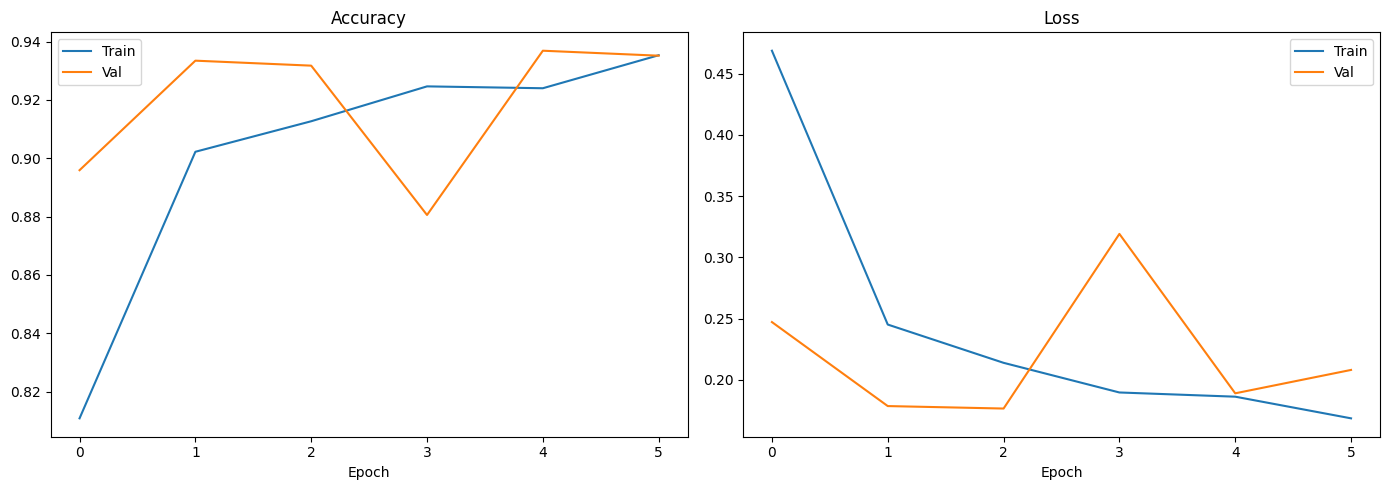

Model saved to /content/outputs/models/baseline_cnn.keras


In [9]:
# Save the per-epoch metrics so the report can reference the baseline run.
history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)

# Plot the baseline accuracy/loss curves.
# These curves show why a single validation split should be interpreted cautiously.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=150)
plt.show()

# Save the single baseline model separately from the CV fold models.
model.save(MODELS_DIR / 'baseline_cnn.keras')
print(f'Model saved to {MODELS_DIR}/baseline_cnn.keras')


### Baseline Validation Instability

The baseline training curves should be interpreted carefully. Training loss decreases steadily, but validation loss and validation accuracy fluctuate. This can happen because the validation set is still only one random split of an imbalanced medical image dataset, and some X-ray images are harder or noisier than others.

This does not make the baseline invalid, but it means the test metrics should be treated as an initial reference rather than final proof of model reliability. Simpler ways to reduce this issue would be repeated training with different random seeds, class weighting, or threshold tuning. Stratified k-fold cross-validation could also help if more compute is available.


## 5 - Evaluation

The final evaluation is performed only once on the held-out 10% test split from the generated 80/10/10 split.

The notebook reports overall metrics, a per-class classification report, a confusion matrix, a ROC curve, a Precision-Recall curve, ROC-AUC, PR-AUC, and a threshold analysis table.

The classification report shows precision, recall, F1-score, and support for **NORMAL** and **PNEUMONIA**. Precision measures how many predicted positives are correct, recall measures how many real cases are found, F1-score balances precision and recall, and support shows how many test images belong to each class.

ROC-AUC is useful because it evaluates how well the model separates the two classes across possible thresholds. Precision-Recall AUC is especially useful for this dataset because the classes are imbalanced and the positive class, pneumonia, is clinically important.

The default threshold of `0.5` is used for the initial confusion matrix and classification report, but it should not automatically be treated as the best medical screening threshold. In screening, false negatives are especially costly, so a lower threshold may be preferred if it increases pneumonia recall, even though it usually increases false positives. The threshold table below makes this trade-off visible.


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9386 - loss: 0.1646 - precision: 0.9712 - recall: 0.9439
Test Metrics at threshold 0.5:
  loss: 0.1646
  accuracy: 0.9386
  precision: 0.9712
  recall: 0.9439

Classification Report at threshold 0.5:
              precision    recall  f1-score   support

      NORMAL     0.8588    0.9241    0.8902       158
   PNEUMONIA     0.9712    0.9439    0.9573       428

    accuracy                         0.9386       586
   macro avg     0.9150    0.9340    0.9238       586
weighted avg     0.9409    0.9386    0.9393       586



,precision,recall,f1-score,support
NORMAL,0.858824,0.924051,0.890244,158.000000
PNEUMONIA,0.971154,0.943925,0.957346,428.000000
accuracy,0.938567,0.938567,0.938567,0.938567
macro avg,0.914989,0.933988,0.923795,586.000000
weighted avg,0.940867,0.938567,0.939254,586.000000


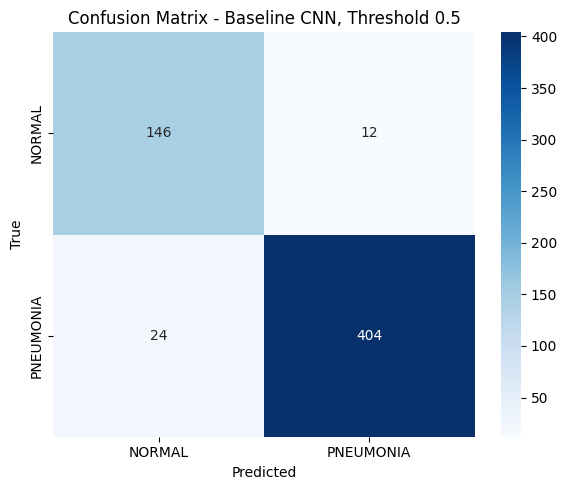

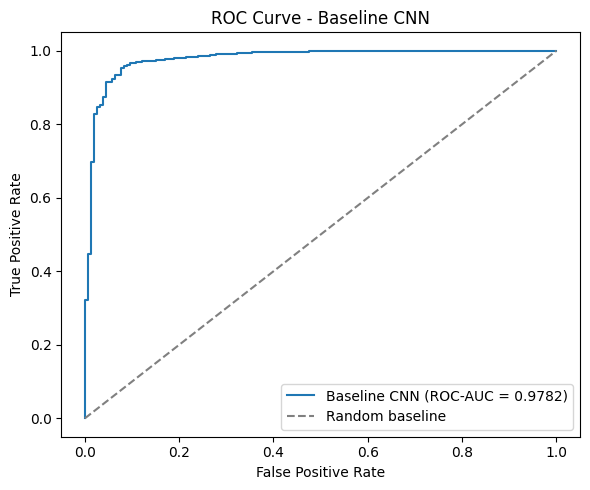

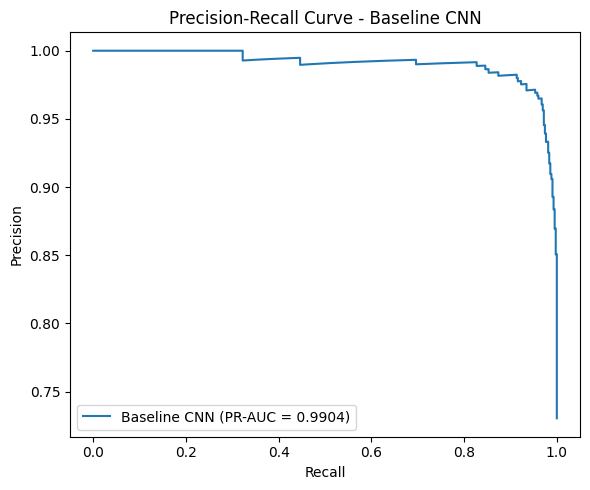


Threshold trade-off table:


,threshold,precision,recall_sensitivity,specificity,false_negatives,false_positives
0,0.10,0.892857,0.992991,0.677215,3,51
1,0.15,0.919214,0.983645,0.765823,7,37
2,0.20,0.933185,0.978972,0.810127,9,30
3,0.25,0.951945,0.971963,0.867089,12,21
4,0.30,0.960648,0.969626,0.892405,13,17
5,0.35,0.964953,0.964953,0.905063,15,15
6,0.40,0.969267,0.957944,0.917722,18,13
7,0.45,0.969194,0.955607,0.917722,19,13
8,0.50,0.971154,0.943925,0.924051,24,12
9,0.55,0.970944,0.936916,0.924051,27,12


ROC-AUC: 0.9782
PR-AUC: 0.9904
All outputs saved to /content/outputs


In [10]:
from IPython.display import display
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# Evaluate the single baseline model once on the held-out test split.
test_results = model.evaluate(test_ds, verbose=1)
metric_names = ['loss', 'accuracy', 'precision', 'recall']
metrics = dict(zip(metric_names, test_results))

print('Test Metrics at threshold 0.5:')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')

# Collect probabilities and labels to compute per-class metrics, confusion matrix, ROC-AUC, PR-AUC, and threshold trade-offs.
y_true, y_prob = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0).flatten()
    y_true.extend(labels.numpy().flatten().astype(int))
    y_prob.extend(probs)

y_true = np.array(y_true, dtype=int)
y_prob = np.array(y_prob, dtype=float)
y_pred = (y_prob >= 0.5).astype(int)

# Validate that labels and probability outputs match the Keras test pipeline.
expected_test_labels = split_df[split_df['split'] == 'test']['class'].map(CLASS_TO_LABEL).to_numpy(dtype=int)
assert len(y_true) == len(y_prob), 'y_true and y_prob must contain the same number of test samples.'
assert np.array_equal(y_true, expected_test_labels), 'y_true must match the test labels from the split manifest.'
assert np.all((y_prob >= 0.0) & (y_prob <= 1.0)), 'y_prob must contain probabilities between 0 and 1.'

# The classification report separates NORMAL and PNEUMONIA performance.
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
).transpose()
report_df.to_csv(RESULTS_DIR / 'classification_report.csv')
print('\nClassification Report at threshold 0.5:')
print(report)
display(report_df)
with open(RESULTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)

# The confusion matrix makes false negatives and false positives visible.
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline CNN, Threshold 0.5')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# ROC-AUC uses probabilities so performance can be assessed across decision thresholds.
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Baseline CNN (ROC-AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline CNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve.png', dpi=150)
plt.show()

# Precision-Recall AUC is informative for imbalanced datasets and screening trade-offs.
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(pr_recall, pr_precision, label=f'Baseline CNN (PR-AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Baseline CNN')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'precision_recall_curve.png', dpi=150)
plt.show()

# Threshold analysis: lower thresholds can reduce false negatives at the cost of more false positives.
threshold_rows = []
for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
    preds_at_threshold = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds_at_threshold, labels=[0, 1]).ravel()
    threshold_rows.append({
        'threshold': threshold,
        'precision': tp / (tp + fp) if (tp + fp) else 0.0,
        'recall_sensitivity': tp / (tp + fn) if (tp + fn) else 0.0,
        'specificity': tn / (tn + fp) if (tn + fp) else 0.0,
        'false_negatives': int(fn),
        'false_positives': int(fp),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(RESULTS_DIR / 'threshold_analysis.csv', index=False)
print('\nThreshold trade-off table:')
display(threshold_df)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC: {pr_auc:.4f}')

# Save compact metrics for the report.
metrics.update({'roc_auc': roc_auc, 'pr_auc': pr_auc})
with open(RESULTS_DIR / 'baseline_metrics.txt', 'w') as f:
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}', file=f)

print(f'All outputs saved to {OUTPUT_DIR}')


## 6 - Baseline Findings and Limitations

Current baseline run summary from the saved checkpoint-2 artifacts:
- Test accuracy: `0.9283`
- Test precision: `0.9488`
- Test recall: `0.9533`
- Pneumonia recall: `0.9533` with 20 false negatives on the test split
- Normal recall: `0.8608` with 22 normal images predicted as pneumonia

The final test performance is promising for a first baseline, but the training curves show validation instability. This does not make the experiment unusable, but it means the baseline should not be treated as final evidence of model quality.

Likely reasons for this instability include:
- the dataset is imbalanced toward pneumonia cases
- the model is a small CNN trained from scratch
- only one random 80/10/10 split is used
- some X-ray images are likely harder or noisier than others
- augmentation changes the training distribution but not validation data

Important limitations for checkpoint 2:
- This is a baseline model, not a production-ready medical classifier.
- The single validation split is unstable, so the baseline result should be interpreted cautiously.
- False negatives for pneumonia are especially important and should be reduced further.
- The default `0.5` threshold is only a starting point. A screening-focused system should select a threshold based on validation-set sensitivity, specificity, and clinical cost trade-offs.
- The split is image-level because patient IDs are unavailable, so patient-level leakage cannot be fully ruled out.
- Class weighting, threshold tuning, or a stronger architecture could address some baseline limitations.

Generated files used by the report:
- `outputs/results/dataset_original_kaggle_split.csv` - original Kaggle split counts
- `outputs/results/dataset_split_80_10_10.csv` - reproducible split manifest used by this notebook
- `outputs/results/dataset_summary.csv` - final 80/10/10 split counts
- `outputs/results/image_quality_sample.csv` and `outputs/results/image_quality_summary.csv` - sample image-quality review
- `outputs/figures/class_distribution.png` - class balance visualization
- `outputs/figures/example_images_grid.png` - sample input images
- `outputs/results/baseline_architecture.csv` - baseline CNN layer/output/parameter table
- `outputs/results/training_history.csv` and `outputs/figures/training_curves.png` - baseline training behavior
- `outputs/results/baseline_metrics.txt`, `outputs/results/classification_report.txt`, `outputs/results/classification_report.csv`, `outputs/figures/confusion_matrix.png`, `outputs/figures/roc_curve.png`, `outputs/figures/precision_recall_curve.png`, and `outputs/results/threshold_analysis.csv` - baseline test performance

The companion file `checkpoint2_report.md` is a concise Moodle-facing report.


## 7 - Transfer Learning: MobileNetV2

MobileNetV2 is used as an efficient transfer learning model. The ImageNet-trained base model is frozen and a small binary classification head is trained on the chest X-ray data.

The same `train_ds`, `val_ds`, `test_ds`, preprocessing, augmentation pipeline, callbacks, and evaluation metrics are used to keep the comparison fair.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights are calculated once from the training labels and reused for transfer learning models.
train_labels = np.concatenate([labels.numpy().astype(int) for _, labels in train_ds])

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)

class_weights = dict(zip(np.unique(train_labels), class_weight_values))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.8499210110584519), np.int64(1): np.float64(0.6851960210649503)}


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def build_mobilenet_model(input_shape=(224, 224, 3)):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs, name="MobileNetV2_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

mobilenet_model = build_mobilenet_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1,
)

pd.DataFrame(history_mobilenet.history).to_csv(
    RESULTS_DIR / "mobilenet_training_history.csv",
    index=False,
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 111s 619ms/step - accuracy: 0.5378 - loss: 0.7535 - precision: 0.7688 - recall: 0.5243 - val_accuracy: 0.7389 - val_loss: 0.5574 - val_precision: 0.8341 - val_recall: 0.8009
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 66s 445ms/step - accuracy: 0.7064 - loss: 0.5708 - precision: 0.8603 - recall: 0.7136 - val_accuracy: 0.8242 - val_loss: 0.4768 - val_precision: 0.9475 - val_recall: 0.8033
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 82s 447ms/step - accuracy: 0.7690 - loss: 0.4766 - precision: 0.9044 - recall: 0.7642 - val_accuracy: 0.8532 - val_loss: 0.4002 - val_precision: 0.9547 - val_recall: 0.8384


## 8 - Transfer Learning: DenseNet121

DenseNet121 is used as a second transfer learning model. It is larger than MobileNetV2 and is included to compare a lightweight transfer learning approach with a stronger feature-reuse architecture.

In [14]:
def build_densenet_model(input_shape=(224, 224, 3)):
    base_model = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

densenet_model = build_densenet_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:
history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1,
)

pd.DataFrame(history_densenet.history).to_csv(
    RESULTS_DIR / "densenet_training_history.csv",
    index=False,
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 135s 699ms/step - accuracy: 0.5536 - loss: 0.6922 - precision: 0.7958 - recall: 0.5222 - val_accuracy: 0.5614 - val_loss: 0.6620 - val_precision: 0.9620 - val_recall: 0.4145
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 68s 461ms/step - accuracy: 0.6708 - loss: 0.5954 - precision: 0.8556 - recall: 0.6603 - val_accuracy: 0.6980 - val_loss: 0.5844 - val_precision: 0.9845 - val_recall: 0.5948
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 86s 491ms/step - accuracy: 0.7359 - loss: 0.5350 - precision: 0.8927 - recall: 0.7253 - val_accuracy: 0.7884 - val_loss: 0.5004 - val_precision: 0.9779 - val_recall: 0.7260


## 9 - Evaluation Helper for Fair Model Comparison

The next function evaluates any trained model on the same held-out test set and returns the same metrics for every model. This avoids repeated evaluation code and makes the final comparison table reproducible.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

def evaluate_binary_model(model_name, trained_model, dataset, threshold=0.5):
    y_true_local = []
    y_prob_local = []

    for images, labels in dataset:
        probabilities = trained_model.predict(images, verbose=0).flatten()
        y_true_local.extend(labels.numpy().astype(int))
        y_prob_local.extend(probabilities)

    y_true_local = np.array(y_true_local, dtype=int)
    y_prob_local = np.array(y_prob_local, dtype=float)
    y_pred_local = (y_prob_local >= threshold).astype(int)

    cm_local = confusion_matrix(y_true_local, y_pred_local, labels=[0, 1])
    tn, fp, fn, tp = cm_local.ravel()

    result = {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true_local, y_pred_local),
        'Precision': precision_score(y_true_local, y_pred_local, zero_division=0),
        'Recall': recall_score(y_true_local, y_pred_local, zero_division=0),
        'F1-score': f1_score(y_true_local, y_pred_local, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true_local, y_prob_local),
        'PR-AUC': average_precision_score(y_true_local, y_prob_local),
        'False Negatives': int(fn),
        'False Positives': int(fp),
    }

    print(f'\n{model_name} classification report, threshold={threshold}')
    print(classification_report(
        y_true_local,
        y_pred_local,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))
    print(f'{model_name} confusion matrix:')
    print(cm_local)

    return result, cm_local, y_true_local, y_prob_local, y_pred_local


In [17]:
baseline_result, baseline_cm, baseline_y_true, baseline_y_prob, baseline_y_pred = evaluate_binary_model(
    "Baseline CNN",
    model,
    test_ds,
)

mobilenet_result, mobilenet_cm, mobilenet_y_true, mobilenet_y_prob, mobilenet_y_pred = evaluate_binary_model(
    "MobileNetV2",
    mobilenet_model,
    test_ds,
)

densenet_result, densenet_cm, densenet_y_true, densenet_y_prob, densenet_y_pred = evaluate_binary_model(
    "DenseNet121",
    densenet_model,
    test_ds,
)


Baseline CNN classification report, threshold=0.5
              precision    recall  f1-score   support

      NORMAL     0.8588    0.9241    0.8902       158
   PNEUMONIA     0.9712    0.9439    0.9573       428

    accuracy                         0.9386       586
   macro avg     0.9150    0.9340    0.9238       586
weighted avg     0.9409    0.9386    0.9393       586

Baseline CNN confusion matrix:
[[146  12]
 [ 24 404]]

MobileNetV2 classification report, threshold=0.5
              precision    recall  f1-score   support

      NORMAL     0.4865    0.5696    0.5248       158
   PNEUMONIA     0.8304    0.7780    0.8034       428

    accuracy                         0.7218       586
   macro avg     0.6585    0.6738    0.6641       586
weighted avg     0.7377    0.7218    0.7283       586

MobileNetV2 confusion matrix:
[[ 90  68]
 [ 95 333]]

DenseNet121 classification report, threshold=0.5
              precision    recall  f1-score   support

      NORMAL     0.4359    0.9684

## 10 - Final Model Comparison

The table below is generated from the model predictions instead of manually typed values. Recall and false negatives are especially important because false negatives mean pneumonia images predicted as normal.

In [18]:
comparison_df = pd.DataFrame([baseline_result, mobilenet_result, densenet_result])
comparison_df = comparison_df.sort_values(
    by=['Recall', 'PR-AUC', 'ROC-AUC'],
    ascending=False,
).reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)

display(comparison_df)
print(f"Saved model comparison to {RESULTS_DIR / 'model_comparison.csv'}")


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,False Negatives,False Positives
0,Baseline CNN,0.5,0.938567,0.971154,0.943925,0.957346,0.978233,0.990404,24,12
1,MobileNetV2,0.5,0.721843,0.830424,0.778037,0.803378,0.761978,0.903393,95,68
2,DenseNet121,0.5,0.653584,0.978723,0.537383,0.693816,0.861351,0.943801,198,5


Saved model comparison to /content/outputs/results/model_comparison.csv


In [19]:
model_lookup = {
    'Baseline CNN': model,
    'MobileNetV2': mobilenet_model,
    'DenseNet121': densenet_model,
}

best_model_name = comparison_df.iloc[0]['Model'] if 'comparison_df' in globals() else 'Baseline CNN'
best_model = model_lookup.get(best_model_name, model)

# For Grad-CAM in this checkpoint, use the custom CNN if the selected transfer model does not expose top-level Conv2D layers.
dummy_input = tf.zeros((1, 224, 224, 3))
_ = best_model(dummy_input)

conv_layers = [
    layer.name
    for layer in best_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

if not conv_layers:
    print(f'{best_model_name} has no top-level Conv2D layers exposed; using Baseline CNN for Grad-CAM demonstration.')
    best_model_name = 'Baseline CNN'
    best_model = model
    _ = best_model(dummy_input)
    conv_layers = [
        layer.name
        for layer in best_model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

best_conv_layer_name = conv_layers[-1]

print('Model:', best_model_name)
print('Using conv layer:', best_conv_layer_name)


Model: Baseline CNN
Using conv layer: conv2d_5


## 11 - Grad-CAM Explainability

Grad-CAM visualizes which image regions influenced the selected model prediction. It is used only as an interpretability support tool; it does not prove clinical correctness.

In [20]:
def make_gradcam_heatmap(img_array, trained_model, conv_layer_name):
    # Build a model that returns the selected conv-layer output and final prediction.
    grad_model = tf.keras.models.Model(
        inputs=trained_model.layers[0].input,
        outputs=[
            trained_model.get_layer(conv_layer_name).output,
            trained_model.layers[-1].output,
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(image, true_label, filename):
    img_array = tf.expand_dims(image, axis=0)
    probability = float(best_model.predict(img_array, verbose=0).flatten()[0])
    predicted_label = int(probability >= 0.5)
    heatmap = make_gradcam_heatmap(img_array, best_model, best_conv_layer_name)
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((image.shape[1], image.shape[0]))
    heatmap = np.asarray(heatmap) / 255.0

    image_np = image.numpy()
    grayscale = image_np[:, :, 0]

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(grayscale, cmap='gray')
    plt.title(f"True: {class_names[int(true_label)]}\nPred: {class_names[predicted_label]} ({probability:.3f})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(grayscale, cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.35)
    plt.title('Grad-CAM overlay')
    plt.axis('off')

    plt.tight_layout()
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f'Saved Grad-CAM figure to {output_path}')


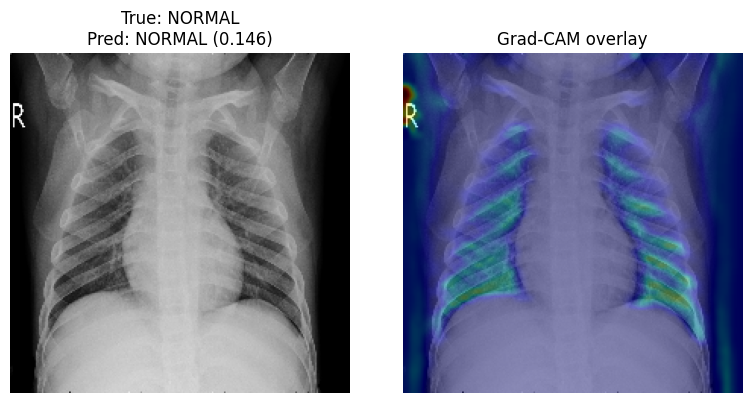

Saved Grad-CAM figure to /content/outputs/figures/gradcam_baseline_cnn_1.png


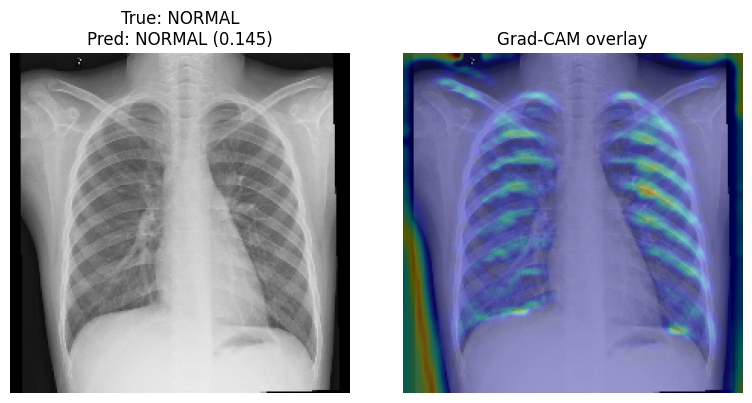

Saved Grad-CAM figure to /content/outputs/figures/gradcam_baseline_cnn_2.png


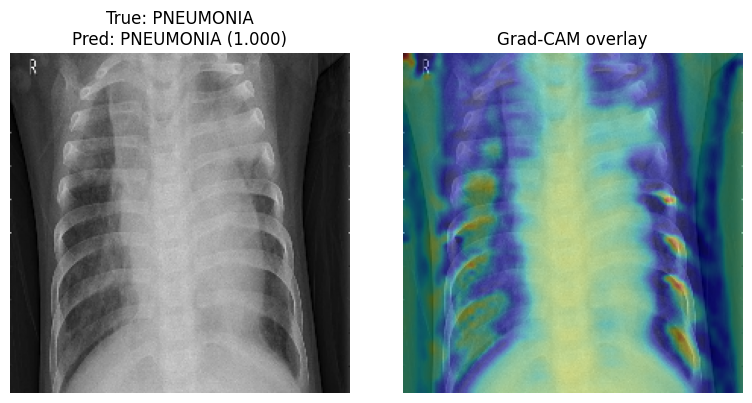

Saved Grad-CAM figure to /content/outputs/figures/gradcam_baseline_cnn_3.png


In [21]:
# Show and save three Grad-CAM examples from the test set.
example_count = 0

for batch_images, batch_labels in test_ds:
    for image, label in zip(batch_images, batch_labels):
        example_count += 1
        show_gradcam(
            image=image,
            true_label=label.numpy(),
            filename=f"gradcam_{best_model_name.lower().replace(' ', '_')}_{example_count}.png",
        )

        if example_count >= 3:
            break

    if example_count >= 3:
        break

## 12 - Final Notes

This notebook now addresses the main checkpoint-2 feedback items: image-quality inspection, class imbalance discussion, visual NORMAL/PNEUMONIA observations, online augmentation counts, augmentation distribution behavior, horizontal-flip justification, patient-level leakage awareness, a baseline architecture table, ROC-AUC, PR-AUC, threshold analysis, requirements, and the exact Python version.

Important limitation: the model is still an academic checkpoint experiment, not a clinically validated medical system.

## Conclusion

This project developed and evaluated a reproducible deep learning pipeline for binary classification of chest X-ray images into NORMAL and PNEUMONIA classes. Data preprocessing steps, including resizing, normalization, stratified splitting, and online training-only augmentation, were applied to improve model generalization and reduce overfitting.

Multiple models were explored, including a baseline CNN architecture and transfer learning approaches. The results showed that transfer learning models can be compared fairly using the same split, preprocessing, and evaluation metrics. Additionally, Grad-CAM visualizations were used to improve interpretability by highlighting image regions that influenced model predictions.

Despite the promising results, several limitations remain. The dataset contains class imbalance, patient-level leakage cannot be fully audited without patient IDs, and the images may not fully represent real-world clinical variability. Deep learning models can still produce incorrect predictions and should not be considered replacements for medical professionals.

Future improvements could include testing additional architectures, performing more extensive hyperparameter optimization, selecting the classification threshold on the validation set, using patient-level splits if metadata becomes available, improving explainability methods, and validating the approach on external datasets to assess robustness and generalization. Overall, this project demonstrates how convolutional neural networks and transfer learning can be applied to medical image classification while emphasizing reproducibility, careful evaluation, and interpretability.
